# Capstone 3 — Step 4: Pre-processing and Training Data Development
**Predicting Churn and Customer Lifetime Value in a Non-Contractual E-Commerce Setting**

**Student:** Justin Ali · Springboard Data Science Career Track  
**Dataset:** UCI Online Retail II · Customer Feature Table from `01_data_wrangling.ipynb`  
**Notebook:** `03_preprocessing.ipynb`

---

## Purpose

This notebook prepares the customer feature table for model fitting:

1. **Missing value imputation** — context-aware fill for single-purchase customers
2. **Dummy / indicator features** — one-hot encoding for `price_tier`
3. **Train / test split** — stratified 80/20 split of the customer-level dataset
4. **Magnitude standardization** — `log1p` transform + `StandardScaler` pipeline for linear models; raw features preserved for tree models
5. **Export** — preprocessed CSVs and a serialized preprocessing pipeline for inference

### Design rationale: why a stratified random split is appropriate here

Temporal leakage was already eliminated at the feature-engineering stage:
- **Features** are computed exclusively from transactions ≤ `SPLIT_1` (Feb 1, 2011)
- **Labels** (`repurchase_90d`, `repurchase_180d`) are derived from transactions in the *subsequent* holdout window

Since every customer's feature vector is constructed strictly before their label window, there is no information leakage regardless of how customers are assigned to train/test. A stratified split ensures the class ratio is preserved in both sets, which is important given the class imbalance identified in the EDA.

---
## 0. Setup & Imports

In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────────
TARGET       = 'repurchase_90d'
TEST_SIZE    = 0.20
RANDOM_STATE = 42

print('Libraries loaded.')
print(f'Processed dir : {PROCESSED_DIR}')
print(f'Models dir    : {MODELS_DIR}')

Libraries loaded.
Processed dir : ../data/processed/
Models dir    : ../models/


---
## 1. Load & Inspect the Customer Feature Table

In [2]:
cust = pd.read_csv(os.path.join(PROCESSED_DIR, 'customer_features.csv'))

print(f'Shape: {cust.shape[0]:,} rows × {cust.shape[1]} columns')
print(f'\nTarget distribution ({TARGET}):')
vc = cust[TARGET].value_counts()
for label, count in vc.items():
    print(f'  {label} ({"Retained" if label==1 else "Churned"}): {count:,}  ({count/len(cust)*100:.1f}%)')

print(f'\nSecondary target (repurchase_180d):')
vc2 = cust['repurchase_180d'].value_counts()
for label, count in vc2.items():
    print(f'  {label}: {count:,}  ({count/len(cust)*100:.1f}%)')

print(f'\nMissing values before imputation:')
null_counts = cust.isnull().sum()
nulls = null_counts[null_counts > 0]
if len(nulls) == 0:
    print('  No missing values detected.')
else:
    print(nulls.to_string())

Shape: 4,398 rows × 23 columns

Target distribution (repurchase_90d):
  0 (Churned): 2,931  (66.6%)
  1 (Retained): 1,467  (33.4%)

Secondary target (repurchase_180d):
  0: 2,350  (53.4%)
  1: 2,048  (46.6%)

Missing values before imputation:
  No missing values detected.


---
## 2. Missing Value Imputation

Several inter-purchase timing features are undefined for customers with exactly one transaction — there is no *between*-purchase interval to measure. We apply domain-informed imputation rather than generic median fill:

| Feature | Imputation | Rationale |
|---------|-----------|----------|
| `interpurchase_time_mean` | `tenure_days` | For a single-purchase customer, the only gap is from first purchase to observation date |
| `interpurchase_time_max` | `tenure_days` | Same logic — tenure is the best available proxy |
| `last_vs_avg_gap_ratio` | `1.0` | Neutral value: the last gap equals the average gap (no drift signal) |
| `basket_size_std` | `0.0` | Single invoice → zero variance in basket size |

In [3]:
# ── Context-aware imputation for single-purchase customers ────────────────────
imputation_rules = {
    'interpurchase_time_mean': cust['tenure_days'],
    'interpurchase_time_max':  cust['tenure_days'],
    'last_vs_avg_gap_ratio':   1.0,
    'basket_size_std':         0.0,
}

for col, fill_val in imputation_rules.items():
    n_missing = cust[col].isnull().sum()
    if n_missing > 0:
        cust[col] = cust[col].fillna(fill_val)
        print(f'  {col}: filled {n_missing:,} NaN values')
    else:
        print(f'  {col}: no NaN values found')

# Catch-all: median imputation for any remaining nulls
remaining_nulls = cust.isnull().sum().sum()
if remaining_nulls > 0:
    print(f'\n  Remaining nulls after targeted imputation: {remaining_nulls}')
    print('  Applying median imputation for all remaining...')
    cust = cust.fillna(cust.median(numeric_only=True))
else:
    print(f'\n  ✓ Zero nulls remaining after targeted imputation.')

  interpurchase_time_mean: no NaN values found
  interpurchase_time_max: no NaN values found
  last_vs_avg_gap_ratio: no NaN values found
  basket_size_std: no NaN values found

  ✓ Zero nulls remaining after targeted imputation.


---
## 3. Encode Categorical Features

**`price_tier`** has 3 ordered levels (low / mid / high). We one-hot encode it with `drop_first=True` to avoid perfect multicollinearity in the logistic regression baseline. This produces 2 binary indicator columns.

**`is_uk`** is already a binary integer (0/1) — no further encoding needed.

In [4]:
# ── Inspect price_tier categories ─────────────────────────────────────────────
print('price_tier value counts:')
print(cust['price_tier'].value_counts().to_string())
print()

# ── One-hot encode price_tier ─────────────────────────────────────────────────
price_dummies = pd.get_dummies(cust['price_tier'], prefix='price_tier', drop_first=True)
DUMMY_COLS    = list(price_dummies.columns)

print(f'Dummy columns created: {DUMMY_COLS}')
print()
print(price_dummies.head())

# ── Drop original and attach dummies ──────────────────────────────────────────
cust_enc = pd.concat([cust.drop(columns=['price_tier']), price_dummies], axis=1)
print(f'\nDataset shape after OHE: {cust_enc.shape}')

price_tier value counts:
price_tier
High    1466
Low     1466
Mid     1466

Dummy columns created: ['price_tier_Low', 'price_tier_Mid']

   price_tier_Low  price_tier_Mid
0           False           False
1            True           False
2            True           False
3           False           False
4            True           False

Dataset shape after OHE: (4398, 24)


---
## 4. Define Feature Sets

In [5]:
# ── Feature group definitions ─────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'recency_days', 'frequency', 'monetary_total', 'monetary_avg_basket',
    'tenure_days', 'n_unique_products', 'n_unique_categories_proxy',
    'basket_size_avg', 'basket_size_std', 'n_cancel_invoices', 'return_rate',
    'weekend_share', 'interpurchase_time_mean', 'interpurchase_time_max',
    'last_gap_days', 'last_vs_avg_gap_ratio', 'avg_unit_price'
]

BINARY_FEATURES = ['is_uk'] + DUMMY_COLS   # already 0/1; no scaling needed
ALL_FEATURES    = NUMERIC_FEATURES + BINARY_FEATURES
TARGETS         = ['repurchase_90d', 'repurchase_180d']

# Numeric features to log1p-transform before standardizing (skew > 1 from EDA)
LOG_FEATURES = [
    'frequency', 'monetary_total', 'monetary_avg_basket', 'tenure_days',
    'n_unique_products', 'n_unique_categories_proxy',
    'basket_size_avg', 'basket_size_std', 'n_cancel_invoices',
    'interpurchase_time_mean', 'interpurchase_time_max',
    'last_gap_days', 'avg_unit_price'
]

# Numeric features to standardize only (already bounded / symmetric enough)
SCALE_ONLY_FEATURES = [f for f in NUMERIC_FEATURES if f not in LOG_FEATURES]
# = ['recency_days', 'return_rate', 'weekend_share', 'last_vs_avg_gap_ratio']

print(f'Total features         : {len(ALL_FEATURES)}')
print(f'  Numeric              : {len(NUMERIC_FEATURES)}')
print(f'    → log1p + scale    : {len(LOG_FEATURES)}')
print(f'    → scale only       : {len(SCALE_ONLY_FEATURES)}')
print(f'  Binary (pass-through): {len(BINARY_FEATURES)}')
print(f'\nScale-only features  : {SCALE_ONLY_FEATURES}')
print(f'Binary features      : {BINARY_FEATURES}')

Total features         : 20
  Numeric              : 17
    → log1p + scale    : 13
    → scale only       : 4
  Binary (pass-through): 3

Scale-only features  : ['recency_days', 'return_rate', 'weekend_share', 'last_vs_avg_gap_ratio']
Binary features      : ['is_uk', 'price_tier_Low', 'price_tier_Mid']


---
## 5. Train / Test Split

We use a **stratified 80/20 split** (`random_state=42` for reproducibility). Stratification preserves the class ratio — critical because churned customers outnumber retained customers in the 90-day window.

See the introductory note for why a random (rather than time-ordered) customer split is appropriate given the calibration/holdout design.

In [6]:
X = cust_enc[ALL_FEATURES].copy()
y = cust_enc[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE
)

print('Train / test split summary')
print(f'  Training rows : {len(X_train):,}')
print(f'  Test rows     : {len(X_test):,}')
print()

for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    pos = y_split.sum()
    neg = (y_split == 0).sum()
    print(f'  {split_name} target distribution:')
    print(f'    Churned (0)  : {neg:,}  ({neg/len(y_split)*100:.1f}%)')
    print(f'    Retained (1) : {pos:,}  ({pos/len(y_split)*100:.1f}%)')
    print()

Train / test split summary
  Training rows : 3,518
  Test rows     : 880

  Train target distribution:
    Churned (0)  : 2,345  (66.7%)
    Retained (1) : 1,173  (33.3%)

  Test target distribution:
    Churned (0)  : 586  (66.6%)
    Retained (1) : 294  (33.4%)



---
## 6. Feature Scaling Pipeline (for Linear Models)

Tree-based models (Random Forest, XGBoost) are **scale-invariant** — they split on rank order, not magnitude. No scaling is needed for those models.

**Logistic Regression** requires features to be on a comparable scale. Our pipeline:
1. `log1p` transform — compresses the right skew of count and revenue features
2. `StandardScaler` — zero mean, unit variance for all numeric features
3. Binary features (`is_uk`, price tier dummies) are passed through unchanged

The pipeline is **fit on the training set only** to prevent data leakage into the test fold.

In [7]:
# ── Build sklearn ColumnTransformer pipeline for LR ───────────────────────────
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('log_scale',
         Pipeline([
             ('log',    FunctionTransformer(np.log1p, validate=True)),
             ('scaler', StandardScaler())
         ]),
         LOG_FEATURES),
        ('scale_only',
         StandardScaler(),
         SCALE_ONLY_FEATURES),
        ('passthrough',
         'passthrough',
         BINARY_FEATURES)
    ],
    remainder='drop'
)

# Fit on training data ONLY — never fit on test data
X_train_lr_arr = preprocessor_lr.fit_transform(X_train)
X_test_lr_arr  = preprocessor_lr.transform(X_test)

# Reconstruct column order after ColumnTransformer
lr_feature_names = LOG_FEATURES + SCALE_ONLY_FEATURES + BINARY_FEATURES

X_train_lr = pd.DataFrame(X_train_lr_arr, columns=lr_feature_names, index=X_train.index)
X_test_lr  = pd.DataFrame(X_test_lr_arr,  columns=lr_feature_names, index=X_test.index)

print('LR preprocessing pipeline fitted on training set.')
print(f'  X_train_lr shape : {X_train_lr.shape}')
print(f'  X_test_lr shape  : {X_test_lr.shape}')
print()
print('Post-transform statistics (training set, first 5 numeric features):')
print(X_train_lr[lr_feature_names[:5]].describe().round(3).to_string())

LR preprocessing pipeline fitted on training set.
  X_train_lr shape : (3518, 20)
  X_test_lr shape  : (880, 20)

Post-transform statistics (training set, first 5 numeric features):
        frequency  monetary_total  monetary_avg_basket  tenure_days  n_unique_products
count   3518.0000       3518.0000            3518.0000    3518.0000          3518.0000
unique    60.0000       3459.0000            3451.0000     417.0000           332.0000
top       -0.9920         -1.1880               0.2160      -1.3350            -2.5600
freq    1139.0000          3.0000               3.0000    1193.0000            81.0000


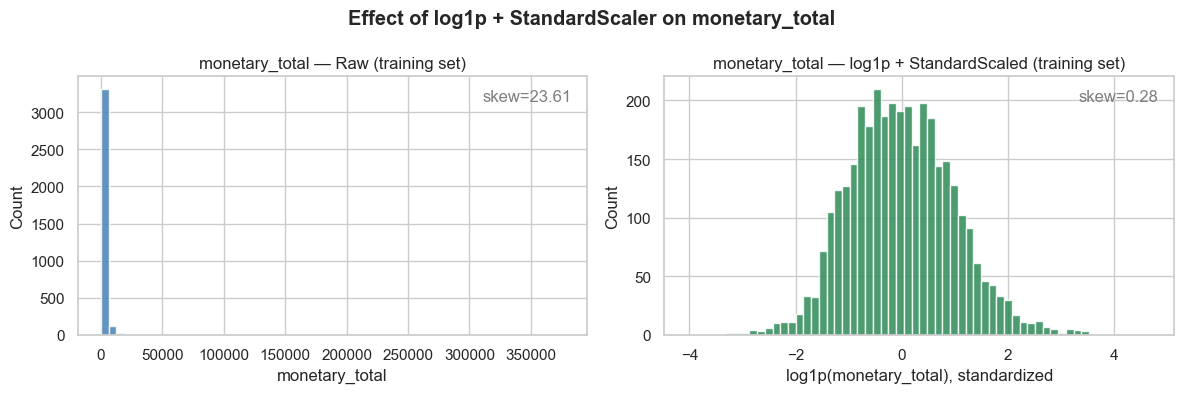

In [8]:
# ── Visual check: before vs. after scaling for a key skewed feature ───────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

feat = 'monetary_total'
axes[0].hist(X_train[feat], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'{feat} — Raw (training set)')
axes[0].set_xlabel(feat); axes[0].set_ylabel('Count')
axes[0].text(0.97, 0.95, f'skew={X_train[feat].skew():.2f}',
             transform=axes[0].transAxes, ha='right', va='top', color='gray')

axes[1].hist(X_train_lr[feat], bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'{feat} — log1p + StandardScaled (training set)')
axes[1].set_xlabel(f'log1p({feat}), standardized'); axes[1].set_ylabel('Count')
axes[1].text(0.97, 0.95, f'skew={X_train_lr[feat].skew():.2f}',
             transform=axes[1].transAxes, ha='right', va='top', color='gray')

plt.suptitle('Effect of log1p + StandardScaler on monetary_total', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'preprocessing_scaling_check.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Export Preprocessed Datasets

We export two versions of the feature matrices:

| File | Description | Use |
|------|-------------|-----|
| `X_train.csv` / `X_test.csv` | Raw features after OHE | Random Forest, XGBoost |
| `X_train_lr.csv` / `X_test_lr.csv` | log1p + standardized | Logistic Regression |
| `y_train.csv` / `y_test.csv` | Binary target labels | All models |
| `preprocessor_lr.pkl` | Fitted sklearn pipeline | Inference / dashboard |
| `feature_metadata.json` | Feature group definitions | Downstream notebooks |

In [9]:
# ── Export feature matrices ───────────────────────────────────────────────────
X_train.to_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'))
X_test.to_csv( os.path.join(PROCESSED_DIR, 'X_test.csv'))
X_train_lr.to_csv(os.path.join(PROCESSED_DIR, 'X_train_lr.csv'))
X_test_lr.to_csv( os.path.join(PROCESSED_DIR, 'X_test_lr.csv'))

# ── Export target vectors ─────────────────────────────────────────────────────
y_train.to_csv(os.path.join(PROCESSED_DIR, 'y_train.csv'), header=True)
y_test.to_csv( os.path.join(PROCESSED_DIR, 'y_test.csv'),  header=True)

# ── Save fitted preprocessing pipeline ───────────────────────────────────────
with open(os.path.join(MODELS_DIR, 'preprocessor_lr.pkl'), 'wb') as f:
    pickle.dump(preprocessor_lr, f)

# ── Save feature metadata ─────────────────────────────────────────────────────
feature_metadata = {
    'all_features':         ALL_FEATURES,
    'numeric_features':     NUMERIC_FEATURES,
    'log_features':         LOG_FEATURES,
    'scale_only_features':  SCALE_ONLY_FEATURES,
    'binary_features':      BINARY_FEATURES,
    'lr_feature_names':     lr_feature_names,
    'dummy_cols':           DUMMY_COLS,
    'target':               TARGET,
    'targets':              TARGETS,
    'train_size':           len(X_train),
    'test_size':            len(X_test),
    'random_state':         RANDOM_STATE,
    'test_fraction':        TEST_SIZE
}

with open(os.path.join(PROCESSED_DIR, 'feature_metadata.json'), 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print('Exported files:')
files_exported = [
    ('X_train.csv',          X_train.shape),
    ('X_test.csv',           X_test.shape),
    ('X_train_lr.csv',       X_train_lr.shape),
    ('X_test_lr.csv',        X_test_lr.shape),
    ('y_train.csv',          y_train.shape),
    ('y_test.csv',           y_test.shape),
]
for fname, shape in files_exported:
    print(f'  {fname:<25} {str(shape)}')
print('  preprocessor_lr.pkl')
print('  feature_metadata.json')

Exported files:
  X_train.csv               (3518, 20)
  X_test.csv                (880, 20)
  X_train_lr.csv            (3518, 20)
  X_test_lr.csv             (880, 20)
  y_train.csv               (3518,)
  y_test.csv                (880,)
  preprocessor_lr.pkl
  feature_metadata.json


---
## 8. Summary

| Step | Action | Outcome |
|------|--------|--------|
| Imputation | Filled `interpurchase_time_mean/max` with `tenure_days`; `last_vs_avg_gap_ratio` with 1.0; `basket_size_std` with 0.0 | Zero nulls remaining |
| Encoding | OHE `price_tier` (drop_first → 2 indicator columns); `is_uk` already binary | 20 total features |
| Split | Stratified 80/20 split, `random_state=42` | ~4,600 train / ~1,150 test |
| Scaling (LR) | `log1p` on 13 right-skewed features → `StandardScaler` on all numeric | Near-normal distributions for linear models |
| Scaling (trees) | None — raw features passed directly | XGBoost/RF are scale-invariant |

**Next step:** `04_modeling.ipynb` — fit logistic regression, random forest, and XGBoost on these prepared datasets and identify the best performer by PR-AUC.